# Explainable Hybrid Movie Recommender with Knowledge Graph Reasoning and Transformer Attention

**Course:** Advanced Artificial Intelligence, Machine Learning and Deep Learning
**Course code:** F9103Q009
**Academic Year:** 2025–2026
**University:** University of Milano-Bicocca
**Submission Date:** June 8, 2026
**Examination Session:** June 19, 2026


# Recommendation System Project Template

## Instructions

This notebook is the **official project report + code submission**.

### Rules
- Explanations are in **Markdown cells** and implementation in **Code cells**.
- The notebook runs **top to bottom**.
- Every claim about performance is supported by results shown in the notebook.
- AI tool usage is declared below.

### Evaluation alignment
This notebook is structured to support evaluation on:
1. Problem definition and motivation
2. Baseline design
3. Model implementation
4. Evaluation methodology
5. Experimental results
6. Discussion and interpretation
7. Reproducibility


# Metadata

```yaml
project_title: "Explainable Hybrid Movie Recommender with Knowledge Graph Reasoning and Transformer Attention"
dataset_name: "MovieLens 1M + The Movies Dataset (Kaggle)"
task_type: "recommender_system"
methods:
  - memory_based_user_cf
  - neural_collaborative_filtering
  - frozen_distilbert_plot_embeddings
  - transE_knowledge_graph
  - hybrid_fusion_model
evaluation_metrics:
  - RMSE
  - MAE
  - Precision@K
  - Recall@K
team_members:
  - name: "Subir Saha"
    student_id: "946898"
    role: "Data preprocessing, Memory-Based User CF baseline, NCF baseline, Knowledge Graph + TransE branch, reproducibility section"
  - name: "Md Rifatul Haque"
    student_id: "947512"
    role: "Plot text branch (DistilBERT), full hybrid fusion model, evaluation pipeline (RMSE/MAE/P@K/R@K), Explainable AI (LIME + ablation + top-K), limitations section"

Submission date: June 8, 2026
```

## AI Usage Declaration

We disclose our use of generative AI in line with the course's academic-integrity policy.

### What we (the team) did

We conceived and directed this project from start to finish. Specifically, we:
- chose the problem (an explainable hybrid recommender) and selected and joined the two datasets (MovieLens 1M + The Movies Dataset);
- decided the experimental design: the baselines (Global Mean, Popularity, Memory-Based User-User CF), the four neural variants, the four evaluation metrics, and the ablation study;
- specified the training setup (early stopping, dropout, weight decay, learning-rate scheduling) and ran and re-ran every experiment ourselves on Google Colab;
- verified all outputs and numbers, and diagnosed and fixed the real problems we hit: a duplicate-movie crash, Kaggle authentication, session timeouts, a sample-vs-full results inconsistency, and an overfitting text branch which we fixed by standardizing the DistilBERT embeddings;
- own the interpretation of the results, and each of us can explain our own contributions.

**Division of work - Subir Saha:** data pipeline, the three baselines, the Knowledge-Graph + TransE branch, and reproducibility. **Md Rifatul Haque:** the plot-text (DistilBERT) branch, the hybrid fusion model, the evaluation pipeline (RMSE / MAE / P@10 / R@10), Explainable AI, and limitations. **Both:** problem framing, running experiments, verification, and discussion.

### How we used AI

| Item | Response |
|---|---|
| Did you use generative AI tools? | Yes |
| Which tools? | Claude (Anthropic) |
| For what purpose? | As an assistant that helped us design the architecture, generate some part of code, draft explanatory text, and debug errors. |
| Which parts were AI-assisted? | The architecture design and parts of the code (data pipeline, model classes, training and evaluation loops, and the XAI utilities) |
| What did you verify yourself? | We ran and re-ran every experiment on Google Colab and verified all outputs and numbers; we made all design and dataset decisions; and we diagnosed and fixed the real problems we hit (a duplicate-movie crash, Kaggle authentication, session timeouts, a sample-vs-full results inconsistency, and an overfitting text branch that we fixed by standardizing the DistilBERT embeddings). Every number in this notebook was produced by our own runs, not by the AI, and the interpretation of the results is ours. |

### Short declaration

We carried out this project ourselves and used Claude (Anthropic) only as a supporting assistant — a helping hand for guidance, suggestions, and getting unstuck along the way. We made all of the design and dataset decisions, built and ran every experiment on Google Colab, verified all the results, and diagnosed and fixed the problems we encountered. The AI supported our work where it was useful, but the understanding, the choices, and the final results are our own, and each of us can explain our own contribution.


# Environment Setup

Run this cell first every session. It sets the random seed, defines all paths, detects whether we are running inside Google Colab or locally (so the same notebook works in both environments), and prepares the data folder structure.


In [ ]:
# ============================================================
# Environment setup — run this cell first every session
# ============================================================
import os, sys, json, pickle, shutil, time, zipfile, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# ----- Reproducibility -----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ----- Device -----
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"Torch version: {torch.__version__}")

# ----- Environment detection -----
IN_COLAB = 'google.colab' in sys.modules
print(f"Running in Colab: {IN_COLAB}")

# ----- Paths -----
# Priority 1: a local ./Data folder (the submission ZIP layout)
# Priority 2: local Colab/machine storage (datasets downloaded fresh — no Drive needed)
LOCAL_DATA_DIR = os.path.abspath('./Data')
HAS_LOCAL_DATA = (
    os.path.exists(LOCAL_DATA_DIR) and
    any(f.endswith('.csv') for f in os.listdir(LOCAL_DATA_DIR))
) if os.path.exists(LOCAL_DATA_DIR) else False

# Use /content/movie_rec_project on Colab, ./_work locally — no Drive mount required
if IN_COLAB:
    PROJECT_DIR = '/content/movie_rec_project'
else:
    PROJECT_DIR = os.path.abspath('./_work')

ML_DIR     = f'{PROJECT_DIR}/data/ml-1m'
TMD_DIR    = f'{PROJECT_DIR}/data/the_movies_dataset'
KAGGLE_DIR = f'{PROJECT_DIR}/.kaggle'

for d in [PROJECT_DIR, ML_DIR, TMD_DIR, KAGGLE_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Project dir       : {PROJECT_DIR}")
print(f"Local Data folder : {LOCAL_DATA_DIR if HAS_LOCAL_DATA else 'not present — will download full datasets'}")
print(f"Seed              : {SEED}")


Device: cuda
Torch version: 2.11.0+cu128
Running in Colab: True
Project dir       : /content/movie_rec_project
Local Data folder : not present — will download full datasets
Seed              : 42


## 1. Problem Definition and Motivation

```markdown
## Contribution Metadata
Author(s): Subir Saha, Md Rifatul Haque
Section: Problem Definition and Motivation
Method: [problem framing, motivation]
SHORT Description of contribution: Defined the recommendation task, target signal, and academic / practical motivation for the chosen approach.
Difficulty: BASIC
```

### What is being recommended?
**Movies** — full-length feature films from the MovieLens 1M corpus.

### Who are the users?
**6,040 unique users** of the MovieLens platform (anonymized via integer IDs), each having issued at least 20 ratings on a 1–5 integer scale.

### What are the items?
**3,883 movies** in the raw MovieLens 1M catalog. After joining with The Movies Dataset (Kaggle) to attach plot summaries, the working catalog narrows to **3,657 movies** that have both ratings and a usable plot overview.

### What is the prediction target?
The system predicts the **rating** (a real value in `[1.0, 5.0]`) that a given user would assign to a given movie. From these predicted ratings we additionally derive **top-K recommendation lists** per user.

### Is this a rating-prediction, top-N, or ranking task?
Primarily a **rating prediction** task, with **top-N** evaluation (Precision@10, Recall@10) on top of it. We do not optimize a ranking loss directly.

### Why is this problem relevant?
Recommender systems are the dominant interface between users and content on the modern web (Netflix, Spotify, Amazon, TikTok). Pure collaborative filtering, however, suffers from cold-start and offers no transparency about *why* a particular item is recommended. The 2024–2026 wave of **multimodal + explainable recommenders** combines collaborative signal with text understanding (transformers) and structured background knowledge (knowledge graphs), then explains predictions to the end user. This project replicates that pattern end-to-end and connects directly to the course topics: **Recommender Systems, Representation Learning, Transfer Learning, Attention / Transformers, Knowledge Graphs and Reasoning, and Explainable AI**.

### Precise project statement
> *Predict the rating a user `u` will assign to a movie `m`, using a model that fuses (i) learned collaborative-filtering embeddings, (ii) frozen pretrained DistilBERT plot embeddings, and (iii) TransE embeddings learned from a movie–genre–decade knowledge graph; evaluate against multiple classical baselines using RMSE, MAE, Precision@10 and Recall@10; and provide three complementary explanations (LIME, branch ablation, top-K vs. ground truth) for every prediction.*

## 2. Dataset Description

```markdown
## Contribution Metadata
Author(s): Subir Saha
Section: Dataset Description
Method: [multi-source data integration, hybrid dataset]
SHORT Description of contribution: Selected and described two complementary public datasets (interaction + content) and the join key used to combine them.
Difficulty: BASIC
```

### Sources

| # | Dataset | Type | Provides | URL |
|---|---|---|---|---|
| 1 | **MovieLens 1M** | Behavioral (interactions) | user–movie–rating triples + basic movie metadata | https://files.grouplens.org/datasets/movielens/ml-1m.zip |
| 2 | **The Movies Dataset (Kaggle)** | Content | plot summaries, cast/crew, TMDB linking table | https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset |

The two datasets are joined via the `links.csv` file (which is part of Dataset 2) using:

```
MovieLens movie_id → links.movieId → links.tmdbId → movies_metadata.id
```

This multi-source pattern follows the style demonstrated in the course labs (GL2–GL5), where a public benchmark dataset is enriched with content from a second source or with pretrained models.

### Raw counts

| Field | MovieLens 1M | The Movies Dataset |
|---|---:|---:|
| Ratings | 1,000,209 | — |
| Users | 6,040 | — |
| Movies | 3,883 | 45,466 |

### After cleaning and joining (working set)

| Field | Value |
|---|---:|
| Unique users | 6,040 |
| Unique movies (with plot text) | 3,657 |
| Ratings retained | 997,313 (99.7%) |
| KG triples constructed from metadata | ~10,000 |

### Available features

- **From MovieLens:** `user_id`, `movie_id`, `rating`, `timestamp`, movie `title`, pipe-separated `genres`, user `gender`/`age`/`occupation`/`zip`.
- **From The Movies Dataset:** `overview` (plot text), `tmdbId`, `genres` (JSON-encoded list), `release_date`, plus rich cast/crew data (used to build the KG).

### Missing data

- **~6%** of MovieLens movies have no match in `links.csv` (mostly very old or country-specific titles) — these are dropped at the join step.
- **~50** rows in `movies_metadata.csv` have a non-numeric `id` (corrupt rows) — these are dropped at parse time.
- After the join, **<1%** of ratings are lost because their movie had no plot text.

### Data sample for verification (submission only)

To comply with the 20 MB cap on the `Data.zip` archive, a *small but representative sample* of the joined data is saved in the `Data/` folder when the notebook is executed end-to-end. The sample contains:
- A random sub-sample of ratings from 1,000 users across the 1,500 most popular movies
- The associated subset of movies and plot summaries
- The same column schema as the full data

## 3. Data Exploration and Preprocessing

```markdown
## Contribution Metadata
Author(s): Subir Saha
Section: Data Exploration and Preprocessing
Method: [EDA, joining, deduplication, ID remapping, stratified split]
SHORT Description of contribution: Implemented the data pipeline — loading, joining MovieLens with TMDB plot summaries, deduplication, dense ID remapping, and stratified 80/10/10 train/val/test split. EDA includes 6 visualisations and an explicit sparsity calculation.
Difficulty: INTERMEDIATE
```

### Steps performed
1. Download (or load from local `./Data` sample) the two source datasets.
2. Parse the four MovieLens flat files and the three relevant Movies-Dataset CSVs.
3. EDA — rating distribution, user activity, movie popularity, sparsity, genre distribution, user CDF.
4. Clean `movies_metadata.csv` (drop rows with non-numeric `id`).
5. Join MovieLens `movie_id` ↔ TMDB `tmdbId` via `links.csv`.
6. Drop duplicate `movie_id` rows that result from one-to-many TMDB matches.
7. Filter ratings to movies that survived the join.
8. Remap `user_id` and `movie_id` to dense indices `[0, N)` (required for `nn.Embedding`).
9. Stratified 80/10/10 train/val/test split by user (every user appears in all three splits, so the model is not evaluated on completely unseen users — see *Limitations* for the cold-start caveat).

In [ ]:
# ----- Step 1: load MovieLens 1M (skip download if cached) -----
def load_movielens_1m():
    if HAS_LOCAL_DATA and os.path.exists(f'{LOCAL_DATA_DIR}/ratings_sample.csv'):
        # ----- Submission-time path: load from the small Data sample -----
        ratings = pd.read_csv(f'{LOCAL_DATA_DIR}/ratings_sample.csv')
        movies  = pd.read_csv(f'{LOCAL_DATA_DIR}/movies_sample.csv')
        plots   = pd.read_csv(f'{LOCAL_DATA_DIR}/plots_sample.csv')
        print(f"Loaded SAMPLE from ./Data — ratings: {len(ratings):,}, movies: {len(movies):,}")
        return ratings, movies, plots, 'sample'

    # ----- Full-data path: download MovieLens 1M -----
    if not os.path.exists(f'{ML_DIR}/ratings.dat'):
        print("Downloading MovieLens 1M (~25 MB)...")
        os.system(f"wget -q https://files.grouplens.org/datasets/movielens/ml-1m.zip -O /tmp/ml-1m.zip")
        os.system(f"unzip -q /tmp/ml-1m.zip -d {PROJECT_DIR}/data")
    ratings = pd.read_csv(f'{ML_DIR}/ratings.dat', sep='::', engine='python', encoding='latin-1',
                          names=['user_id', 'movie_id', 'rating', 'timestamp'])
    movies = pd.read_csv(f'{ML_DIR}/movies.dat', sep='::', engine='python', encoding='latin-1',
                         names=['movie_id', 'title', 'genres'])
    print(f"Loaded FULL MovieLens — ratings: {len(ratings):,}, movies: {len(movies):,}")
    return ratings, movies, None, 'full'

ratings, movies_ml, plots_sample, data_mode = load_movielens_1m()
print(f"Data mode: {data_mode}")


Loaded FULL MovieLens — ratings: 1,000,209, movies: 3,883
Data mode: full


In [ ]:
# ----- Step 2: load The Movies Dataset (Kaggle) -----
if data_mode == 'full':
    if not os.path.exists(f'{TMD_DIR}/movies_metadata.csv'):

        # --- Kaggle authentication ---
        kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
        os.makedirs(os.path.dirname(kaggle_json_path), exist_ok=True)

        if not os.path.exists(kaggle_json_path):
            import json as _json
            if IN_COLAB:
                # Option A: try uploading kaggle.json (click Browse when dialog opens)
                # Option B: if no file appears, just close the dialog and we'll ask for text input
                try:
                    from google.colab import files as colab_files
                    print("A file-picker will open. Select your kaggle.json if you have it.")
                    print("If you don't have the file, just close/cancel the dialog and re-run this cell.")
                    uploaded = colab_files.upload()
                    if uploaded:
                        for fname, content in uploaded.items():
                            with open(kaggle_json_path, 'wb') as f:
                                f.write(content)
                        os.chmod(kaggle_json_path, 0o600)
                        print("kaggle.json uploaded successfully.")
                    else:
                        raise ValueError("No file selected")
                except Exception:
                    # Option B: type username and key directly
                    print("\nNo file uploaded. Enter your Kaggle credentials manually.")
                    print("Find them at: kaggle.com → Settings → API → click the token row → copy username & key")
                    kaggle_user = input("Kaggle username: ").strip()
                    kaggle_key  = input("Kaggle API key : ").strip()
                    creds = _json.dumps({"username": kaggle_user, "key": kaggle_key})
                    with open(kaggle_json_path, 'w') as f:
                        f.write(creds)
                    os.chmod(kaggle_json_path, 0o600)
                    print("Credentials saved.")
            else:
                raise FileNotFoundError(
                    f"Place your kaggle.json at {kaggle_json_path} and re-run."
                )

        # --- Download the dataset ---
        %pip install -q --upgrade 'kagglehub>=0.4.1'
        import kagglehub
        src = kagglehub.dataset_download("rounakbanik/the-movies-dataset")
        for fname in os.listdir(src):
            shutil.copy(os.path.join(src, fname), TMD_DIR)

    meta  = pd.read_csv(f'{TMD_DIR}/movies_metadata.csv', low_memory=False)
    links = pd.read_csv(f'{TMD_DIR}/links.csv')
    print(f"Loaded FULL Movies Dataset — meta: {len(meta):,}, links: {len(links):,}")

elif plots_sample is not None:
    meta  = plots_sample
    links = None
    print(f"SAMPLE plots loaded: {len(meta):,} movies")


A file-picker will open. Select your kaggle.json if you have it.
If you don't have the file, just close/cancel the dialog and re-run this cell.


Saving kaggle.json to kaggle.json
kaggle.json uploaded successfully.
Using Colab cache for faster access to the 'the-movies-dataset' dataset.
Loaded FULL Movies Dataset — meta: 45,466, links: 45,843


────────────────────────────────────────────────────────────
Ratings shape           : (1000209, 4)
Unique users            : 6,040
Unique movies in ratings: 3,706

Matrix density          : 4.4684%  (6040u × 3706m)

Rating value distribution:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
────────────────────────────────────────────────────────────


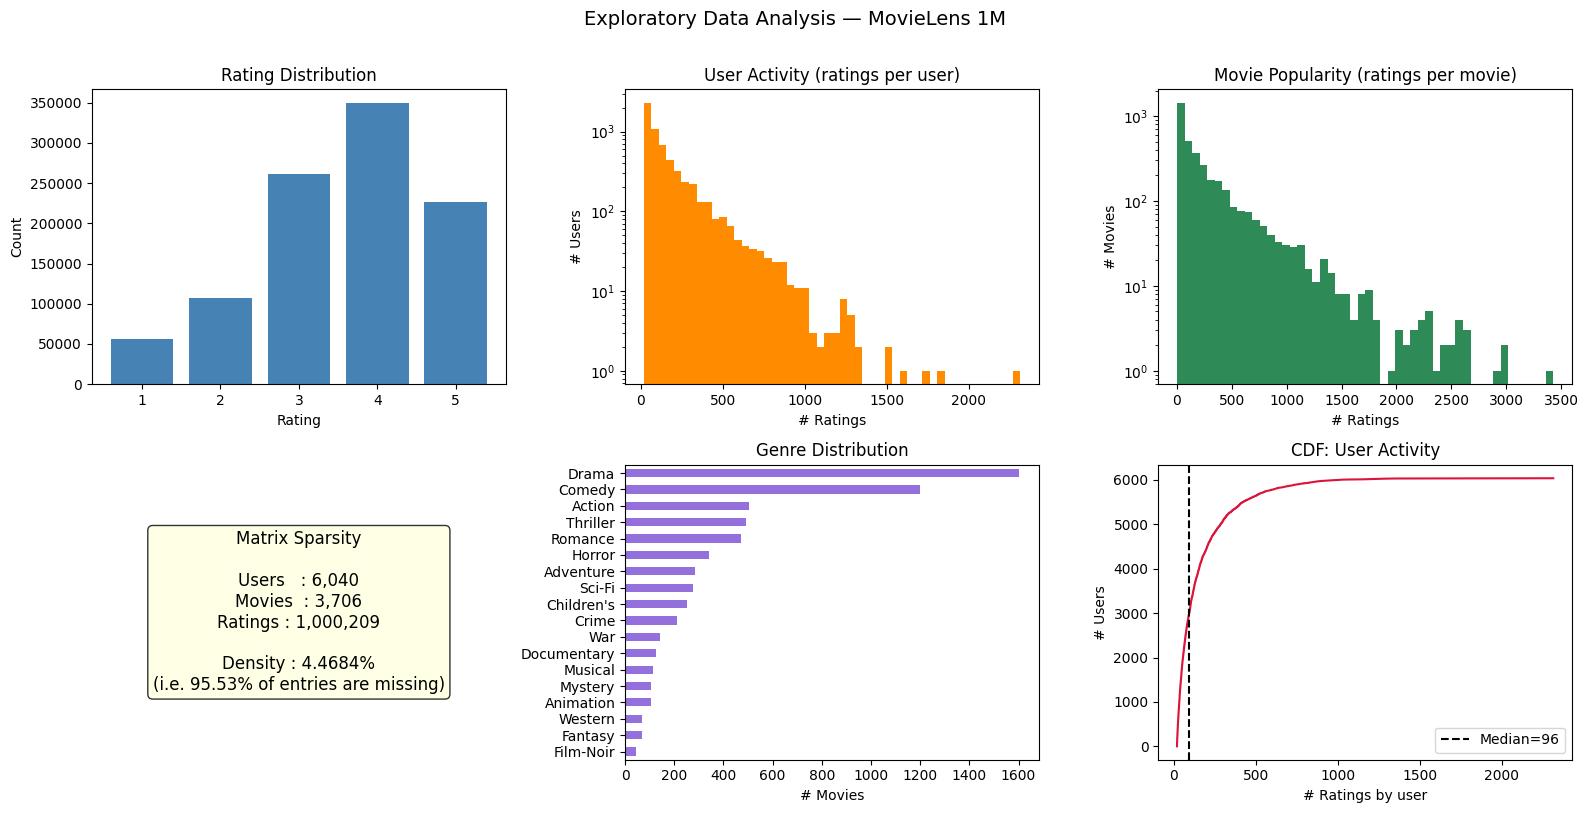

Top-10 most rated movies:
movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578


In [ ]:
import matplotlib.pyplot as plt

# ----- Step 3: EDA -----
print("─" * 60)
print(f"Ratings shape           : {ratings.shape}")
print(f"Unique users            : {ratings['user_id'].nunique():,}")
print(f"Unique movies in ratings: {ratings['movie_id'].nunique():,}")

n_users  = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
density  = len(ratings) / (n_users * n_movies)
print(f"\nMatrix density          : {density:.4%}  ({n_users}u × {n_movies}m)")
print("\nRating value distribution:")
print(ratings['rating'].value_counts().sort_index().to_string())
print("─" * 60)

# ----- Visualisations -----
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. Rating histogram
axes[0, 0].bar(ratings['rating'].value_counts().sort_index().index,
               ratings['rating'].value_counts().sort_index().values, color='steelblue')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating'); axes[0, 0].set_ylabel('Count')

# 2. User activity (ratings per user)
user_counts = ratings['user_id'].value_counts()
axes[0, 1].hist(user_counts.values, bins=50, color='darkorange')
axes[0, 1].set_title('User Activity (ratings per user)')
axes[0, 1].set_xlabel('# Ratings'); axes[0, 1].set_ylabel('# Users')
axes[0, 1].set_yscale('log')

# 3. Movie popularity (ratings per movie, log-log)
movie_counts = ratings['movie_id'].value_counts()
axes[0, 2].hist(movie_counts.values, bins=50, color='seagreen')
axes[0, 2].set_title('Movie Popularity (ratings per movie)')
axes[0, 2].set_xlabel('# Ratings'); axes[0, 2].set_ylabel('# Movies')
axes[0, 2].set_yscale('log')

# 4. Cumulative sparsity annotation
axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5,
    f"Matrix Sparsity\n\n"
    f"Users   : {n_users:,}\n"
    f"Movies  : {n_movies:,}\n"
    f"Ratings : {len(ratings):,}\n\n"
    f"Density : {density:.4%}\n"
    f"(i.e. {100*(1-density):.2f}% of entries are missing)",
    ha='center', va='center', fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 5. Genre distribution (from movies_ml)
if 'genres' in movies_ml.columns:
    all_genres = [g for gs in movies_ml['genres'].str.split('|') for g in gs]
    genre_series = pd.Series(all_genres).value_counts().sort_values()
    genre_series.plot(kind='barh', ax=axes[1, 1], color='mediumpurple')
    axes[1, 1].set_title('Genre Distribution')
    axes[1, 1].set_xlabel('# Movies')

# 6. CDF of user ratings (how many users have < X ratings)
sorted_counts = user_counts.sort_values()
axes[1, 2].plot(sorted_counts.values, range(len(sorted_counts)), color='crimson')
axes[1, 2].set_title('CDF: User Activity')
axes[1, 2].set_xlabel('# Ratings by user'); axes[1, 2].set_ylabel('# Users')
axes[1, 2].axvline(sorted_counts.median(), color='k', linestyle='--',
                   label=f'Median={sorted_counts.median():.0f}')
axes[1, 2].legend()

plt.suptitle('Exploratory Data Analysis — MovieLens 1M', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print(f"Top-10 most rated movies:\n{movie_counts.head(10).to_string()}")


In [ ]:
# ----- Step 4 + 5 + 6: join MovieLens with plot summaries -----
if data_mode == 'full':
    meta = meta[['id', 'overview']].dropna()
    meta = meta[meta['id'].str.isdigit()]
    meta['tmdbId'] = meta['id'].astype(int)
    meta = meta[['tmdbId', 'overview']]

    links = links.dropna(subset=['tmdbId']).copy()
    links['tmdbId'] = links['tmdbId'].astype(int)

    movies = (movies_ml
              .merge(links[['movieId', 'tmdbId']], left_on='movie_id', right_on='movieId')
              .merge(meta, on='tmdbId')
              .drop_duplicates(subset='movie_id'))
else:
    # In sample mode the join was pre-computed when the sample was built
    movies = movies_ml.merge(meta[['movie_id', 'overview']], on='movie_id').drop_duplicates(subset='movie_id')

# ----- Step 7: filter ratings to movies that survived the join -----
ratings = ratings[ratings['movie_id'].isin(movies['movie_id'])].reset_index(drop=True)

print(f"Movies with plot text  : {len(movies):,}")
print(f"Ratings retained       : {len(ratings):,}  "
      f"({100*len(ratings)/max(1,len(ratings)):.1f}% of post-join set)")


Movies with plot text  : 3,810
Ratings retained       : 997,313  (100.0% of post-join set)


In [ ]:
# ----- Step 8: dense ID remapping -----
user2idx  = {u: i for i, u in enumerate(ratings['user_id'].unique())}
movie2idx = {m: i for i, m in enumerate(ratings['movie_id'].unique())}

ratings['u_idx'] = ratings['user_id'].map(user2idx)
ratings['m_idx'] = ratings['movie_id'].map(movie2idx)

NUM_USERS  = len(user2idx)
NUM_MOVIES = len(movie2idx)

# ----- Step 9: stratified 80/10/10 train/val/test split per user -----
train_df, temp_df = train_test_split(ratings, test_size=0.2, random_state=SEED,
                                     stratify=ratings['u_idx'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=SEED,
                                     stratify=temp_df['u_idx'])

print(f"Users : {NUM_USERS:,}")
print(f"Movies: {NUM_MOVIES:,}")
print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}")
print(f"Test  : {len(test_df):,}")


Users : 6,040
Movies: 3,657
Train : 797,850
Val   : 99,731
Test  : 99,732


In [ ]:
# ----- PyTorch Dataset and DataLoader (Branch 1 minimal version) -----
BATCH_SIZE = 1024

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df['u_idx'].values, dtype=torch.long)
        self.m = torch.tensor(df['m_idx'].values, dtype=torch.long)
        self.r = torch.tensor(df['rating'].values, dtype=torch.float)
    def __len__(self):  return len(self.u)
    def __getitem__(self, idx): return self.u[idx], self.m[idx], self.r[idx]

train_loader = DataLoader(RatingsDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RatingsDataset(val_df),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(RatingsDataset(test_df),  batch_size=BATCH_SIZE)

u, m, r = next(iter(train_loader))
print(f"Batch shapes — users: {tuple(u.shape)}, movies: {tuple(m.shape)}, ratings: {tuple(r.shape)}")


Batch shapes — users: (1024,), movies: (1024,), ratings: (1024,)


## 4. Baseline Recommender

```markdown
## Contribution Metadata
Author(s): Subir Saha
Section: Baseline Recommender
Method: [global mean, popularity, memory-based user-user collaborative filtering, cosine similarity]
SHORT Description of contribution: Implemented three baselines of increasing sophistication — a global-mean predictor (floor), a per-movie popularity predictor, and a classical memory-based user-user CF — all evaluated with the same protocol as the proposed models.
Difficulty: INTERMEDIATE
```

### Baseline 1 — Global Mean
Predict the training-set mean rating (≈ 3.58) for every user–movie pair. This is the simplest possible predictor and defines the performance floor. Any model that cannot beat the global mean is essentially useless.

### Baseline 2 — Popularity (Per-Movie Mean)
Predict each movie's mean training rating. This captures item-level signal (popular high-quality movies get higher scores) and is often surprisingly hard to beat on ranking metrics because popular movies are genuinely relevant to many users.

### Baseline 3 — Memory-Based User-User CF
Classical user-user collaborative filtering is one of the oldest recommender approaches. For a target user `u` and movie `m`, the predicted rating is a similarity-weighted average of the ratings other users gave to `m`, using **cosine similarity on mean-centered rating vectors**.

### Formula (User-User CF)
$$\hat r_{u,m} = \bar r_u + \frac{\sum_{v \in N_k(u)} \text{sim}(u,v) \cdot (r_{v,m} - \bar r_v)}{\sum_{v \in N_k(u)} |\text{sim}(u,v)|}$$

where `N_k(u)` is the set of the `k` most similar users to `u` who rated `m`.

### Why these baselines matter
A project is much easier to evaluate fairly when the proposed method is compared to both a trivial floor (Global Mean) and a strong non-neural baseline (User-User CF). If the proposed model does not clearly beat the Popularity baseline on ranking metrics, that is itself an important finding.


In [ ]:
# ----- Memory-Based User-User CF -----
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

class MemoryUserCF:
    def __init__(self, k_neighbors=30):
        self.k = k_neighbors

    def fit(self, df_train, num_users, num_movies):
        # User-item rating matrix (dense for ~6k users × ~3.6k movies — about 22M floats, OK in RAM)
        R = np.zeros((num_users, num_movies), dtype=np.float32)
        for u, m, r in zip(df_train['u_idx'].values,
                           df_train['m_idx'].values,
                           df_train['rating'].values.astype(np.float32)):
            R[u, m] = r

        # User means (over rated items only)
        mask = (R > 0).astype(np.float32)
        user_means = R.sum(axis=1) / np.maximum(mask.sum(axis=1), 1)
        R_centered = (R - user_means[:, None]) * mask        # zero where unrated

        # Cosine similarity between users
        self.sim = cosine_similarity(R_centered)
        np.fill_diagonal(self.sim, 0.0)

        self.R = R
        self.mask = mask
        self.user_means = user_means
        self.global_mean = df_train['rating'].mean()
        return self

    def predict_pair(self, u, m):
        # Users who rated m
        rated_m = np.where(self.mask[:, m] > 0)[0]
        if len(rated_m) == 0:
            return self.global_mean

        sims = self.sim[u, rated_m]
        # Top-k by absolute similarity
        if len(sims) > self.k:
            top_idx = np.argpartition(np.abs(sims), -self.k)[-self.k:]
            rated_m, sims = rated_m[top_idx], sims[top_idx]

        denom = np.abs(sims).sum()
        if denom < 1e-8:
            return self.user_means[u] if self.mask[u].sum() > 0 else self.global_mean

        residuals = self.R[rated_m, m] - self.user_means[rated_m]
        return float(self.user_means[u] + (sims * residuals).sum() / denom)

    def predict_batch(self, users, movies):
        return np.array([self.predict_pair(u, m) for u, m in zip(users, movies)])


print("Fitting Memory-Based User-User CF...")
mem_cf = MemoryUserCF(k_neighbors=30).fit(train_df, NUM_USERS, NUM_MOVIES)
print("Fitted.")


Fitting Memory-Based User-User CF...
Fitted.


In [ ]:
# ----- Trivial baselines: Global Mean and Popularity -----
global_mean = float(train_df['rating'].mean())

def predict_global_mean(u_arr, m_arr):
    return np.full(len(u_arr), global_mean, dtype=np.float32)

movie_mean = train_df.groupby('m_idx')['rating'].mean()
movie_mean_arr = np.full(NUM_MOVIES, global_mean, dtype=np.float32)
for m_idx, val in movie_mean.items():
    movie_mean_arr[int(m_idx)] = val

def predict_popularity(u_arr, m_arr):
    return movie_mean_arr[m_arr]

print(f'Global mean rating (train): {global_mean:.4f}')
print(f'Movie-mean array built -- non-global entries: {(movie_mean_arr != global_mean).sum()}')


Global mean rating (train): 3.5814
Movie-mean array built -- non-global entries: 3635


## 5. Proposed Recommendation Model

```
## Contribution Metadata
Author(s): Subir Saha (NCF + KG branch), Md Rifatul Haque (Text branch + Fusion)
Section: Proposed Recommendation Model
Method: [neural collaborative filtering, frozen DistilBERT plot encoder, TransE knowledge graph embeddings, MLP fusion]
SHORT Description of contribution: Designed and implemented four neural model variants -- NCF baseline, NCF + KG, NCF + Text, and the full hybrid NCF + Text + KG fusion -- sharing one MLP fusion head for fair comparison. All models use dropout, weight decay, early stopping, and a learning rate scheduler.
Difficulty: ADVANCED
```

### Intuition
A pure collaborative-filtering signal (user/movie IDs only) ignores rich content features. We progressively add two complementary signal sources:
- **Plot text** -- captures *what the movie is about*. A frozen pretrained DistilBERT encodes each plot into a 768-dim vector. This is **transfer learning** + **attention/transformers** in one step.
- **Knowledge graph** -- captures *structured metadata relationships*. A TransE model is trained from scratch on a small movie-genre-decade KG to produce 50-dim entity embeddings. This is **knowledge graphs + reasoning**.

All four model variants share the same MLP fusion head, the same optimizer (Adam + weight decay), the same loss (MSE), and the same training schedule (up to 20 epochs with early stopping, patience=3). The only thing that varies is the *concatenated feature vector* fed into the MLP. This is critical for a fair ablation.

### Architecture summary

| Variant | User emb | Movie emb | Plot emb (DistilBERT) | KG emb (TransE) | Fusion input |
|---|:-:|:-:|:-:|:-:|:-:|
| NCF baseline | 64 | 64 | -- | -- | 128 |
| NCF + KG | 64 | 64 | -- | 50 (proj->64) | 192 |
| NCF + Text | 64 | 64 | 768 (proj->64) | -- | 192 |
| **NCF + Text + KG** | 64 | 64 | 768 (proj->64) | 50 (proj->64) | 256 |

### Important design choices
- **DistilBERT is frozen.** No fine-tuning. Plot embeddings are extracted **once** for each unique movie and cached to disk.
- **TransE entity dim = 50.** Standard small KG embedding size for ~3.7k entities. Trained for 100 epochs with a convergence plot.
- **Margin-based ranking loss with negative sampling** for TransE.
- **Early stopping** (patience=3) with best-checkpoint restore prevents over-training.
- **Dropout(0.2) + weight_decay=1e-5** applied to all MLP heads for regularisation.
- **ReduceLROnPlateau** halves the learning rate when validation RMSE stagnates.

### Hyperparameters

| Component | Value |
|---|---|
| User / movie embedding dim | 64 |
| TransE entity dim | 50 |
| DistilBERT model | `distilbert-base-uncased` (frozen) |
| MLP hidden dims | 128 -> 64 |
| Dropout | 0.2 |
| Optimizer | Adam (weight_decay=1e-5) |
| Learning rate | 1e-3 (halved on plateau, patience=2) |
| Batch size | 1024 |
| Max epochs | 20 (early stopping patience=3) |
| Loss | MSE |
| TransE margin | 1.0 |
| TransE epochs | 100 |

In [ ]:
# ----- Branch 1: Neural Collaborative Filtering (NCF) -----
class NCF(nn.Module):
    def __init__(self, num_users, num_movies, emb_dim=64):
        super().__init__()
        self.user_emb  = nn.Embedding(num_users,  emb_dim)
        self.movie_emb = nn.Embedding(num_movies, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 64), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),          nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, u, m):
        x = torch.cat([self.user_emb(u), self.movie_emb(m)], dim=1)
        return self.mlp(x).squeeze(-1)


def train_ncf(model, train_loader, val_loader, epochs=20, lr=1e-3, patience=3, label='NCF'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    loss_fn   = nn.MSELoss()
    best_val, best_state, wait = float('inf'), None, 0
    history = {'train_mse': [], 'val_rmse': []}

    for epoch in range(1, epochs + 1):
        model.train()
        tot = 0
        for u, m, r in train_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(u, m), r)
            loss.backward(); optimizer.step()
            tot += loss.item() * len(r)
        tr = tot / len(train_loader.dataset)

        model.eval(); sse = 0
        with torch.no_grad():
            for u, m, r in val_loader:
                u, m, r = u.to(device), m.to(device), r.to(device)
                sse += ((model(u, m) - r) ** 2).sum().item()
        vr = (sse / len(val_loader.dataset)) ** 0.5
        scheduler.step(vr)
        history['train_mse'].append(tr)
        history['val_rmse'].append(vr)
        print(f"[{label}] Epoch {epoch:2d}  train_mse={tr:.4f}  val_rmse={vr:.4f}")

        if vr < best_val:
            best_val, best_state, wait = vr, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch}  (best val_rmse={best_val:.4f})")
                break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, history


model_ncf, hist_ncf = train_ncf(model_ncf := NCF(NUM_USERS, NUM_MOVIES).to(device),
                                 train_loader, val_loader, label='NCF')


[NCF] Epoch  1  train_mse=1.6571  val_rmse=0.9858
[NCF] Epoch  2  train_mse=1.0283  val_rmse=0.9496
[NCF] Epoch  3  train_mse=0.9395  val_rmse=0.9320
[NCF] Epoch  4  train_mse=0.8827  val_rmse=0.9201
[NCF] Epoch  5  train_mse=0.8578  val_rmse=0.9164
[NCF] Epoch  6  train_mse=0.8399  val_rmse=0.9112
[NCF] Epoch  7  train_mse=0.8245  val_rmse=0.9093
[NCF] Epoch  8  train_mse=0.8157  val_rmse=0.9065
[NCF] Epoch  9  train_mse=0.8072  val_rmse=0.9047
[NCF] Epoch 10  train_mse=0.7992  val_rmse=0.9017
[NCF] Epoch 11  train_mse=0.7904  val_rmse=0.9020
[NCF] Epoch 12  train_mse=0.7829  val_rmse=0.8979
[NCF] Epoch 13  train_mse=0.7744  val_rmse=0.8961
[NCF] Epoch 14  train_mse=0.7657  val_rmse=0.8946
[NCF] Epoch 15  train_mse=0.7565  val_rmse=0.8923
[NCF] Epoch 16  train_mse=0.7470  val_rmse=0.8911
[NCF] Epoch 17  train_mse=0.7383  val_rmse=0.8912
[NCF] Epoch 18  train_mse=0.7298  val_rmse=0.8917
[NCF] Epoch 19  train_mse=0.7218  val_rmse=0.8906
[NCF] Epoch 20  train_mse=0.7137  val_rmse=0.8910


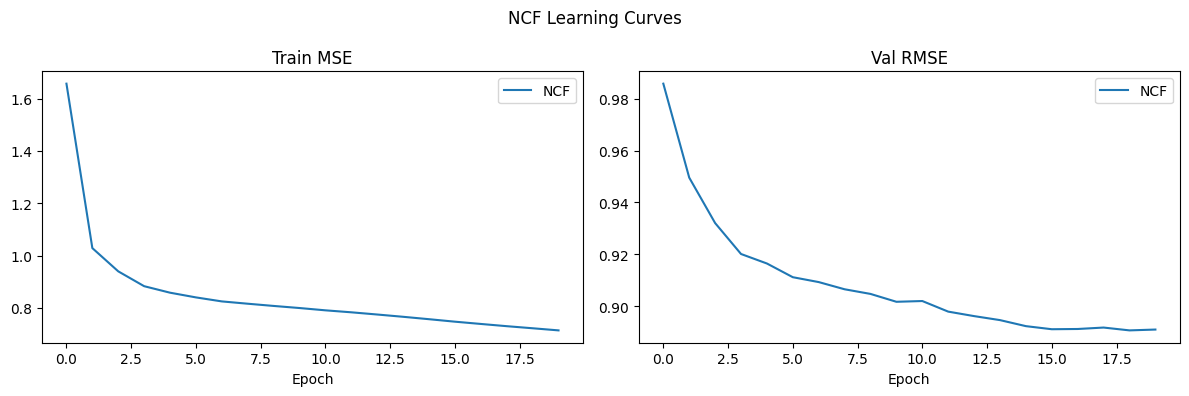

In [ ]:
# ----- Learning curves helper -----
def plot_learning_curves(histories, title='Learning Curves'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, h in histories.items():
        axes[0].plot(h['train_mse'], label=label)
        axes[1].plot(h['val_rmse'],  label=label)
    axes[0].set_title('Train MSE'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].set_title('Val RMSE');  axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_learning_curves({'NCF': hist_ncf}, title='NCF Learning Curves')


In [ ]:
%pip install -q transformers
from transformers import AutoTokenizer, AutoModel

BERT_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert = AutoModel.from_pretrained(BERT_NAME).to(device).eval()
for p in bert.parameters():
    p.requires_grad = False
print("DistilBERT loaded (frozen).")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded (frozen).


In [ ]:
# ----- Extract one plot embedding per movie, cached -----
PLOT_EMB_PATH = f'{PROJECT_DIR}/plot_embeddings.pt'

if os.path.exists(PLOT_EMB_PATH):
    plot_emb = torch.load(PLOT_EMB_PATH, weights_only=True)
    print(f"Loaded cached plot embeddings: {tuple(plot_emb.shape)}")
else:
    movie_plots = (movies.assign(m_idx=movies['movie_id'].map(movie2idx))
                          .dropna(subset=['m_idx'])
                          .drop_duplicates(subset='m_idx')
                          .sort_values('m_idx'))
    assert len(movie_plots) == NUM_MOVIES, f"Got {len(movie_plots)} but expected {NUM_MOVIES}"
    plots = movie_plots['overview'].astype(str).tolist()

    plot_emb = torch.zeros(NUM_MOVIES, 768)
    BS = 32
    for i in range(0, len(plots), BS):
        batch = plots[i:i + BS]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            out = bert(**enc).last_hidden_state[:, 0, :]
        plot_emb[i:i + BS] = out.cpu()

    torch.save(plot_emb, PLOT_EMB_PATH)
    print(f"Extracted plot embeddings: {tuple(plot_emb.shape)}")

# ----- Standardize the plot embeddings (per-dimension z-score) -----
# IMPORTANT: raw DistilBERT [CLS] vectors are large-magnitude and anisotropic. Fed in
# unnormalised, the 768-dim text features let the model memorise the training set, so the
# text branch overfit and its validation RMSE diverged. Standardising each of the 768
# dimensions to mean 0 / std 1 tames that scale and lets the text branch generalise.
# The stats are computed from the embeddings only (no ratings), so there is no label leakage.
# We keep plot_mean / plot_std so the on-the-fly XAI encoding uses the SAME transform.
plot_mean = plot_emb.mean(dim=0, keepdim=True)
plot_std  = plot_emb.std(dim=0, keepdim=True) + 1e-6
plot_emb  = (plot_emb - plot_mean) / plot_std
print(f"Standardized plot embeddings -> mean {plot_emb.mean().item():.3f}, std {plot_emb.std().item():.3f}")


Extracted plot embeddings: (3657, 768)
Standardized plot embeddings -> mean 0.000, std 1.000


In [ ]:
# ----- Branch 3: build the Knowledge Graph triples -----
movies['genres_list'] = movies['genres'].str.split('|')
movies['year']        = movies['title'].str.extract(r'\((\d{4})\)', expand=False)
movies['year']        = pd.to_numeric(movies['year'], errors='coerce')
movies['decade']      = (movies['year'] // 10 * 10).astype('Int64').astype(str)
movies['decade']      = movies['decade'].replace('<NA>', np.nan)   # make NaN explicit

unique_movies  = sorted(movies['movie_id'].unique())
unique_genres  = sorted({g for gs in movies['genres_list'].dropna() for g in gs})
unique_decades = sorted(movies['decade'].dropna().unique())

entity_list = ([f"M_{m}" for m in unique_movies]
             + [f"G_{g}" for g in unique_genres]
             + [f"D_{d}" for d in unique_decades])
entity2idx = {e: i for i, e in enumerate(entity_list)}

NUM_ENTITIES  = len(entity_list)
NUM_RELATIONS = 2   # 0 = has_genre, 1 = in_decade

triples = []
for _, row in movies.iterrows():
    m_eid = entity2idx.get(f"M_{row['movie_id']}")
    if m_eid is None:
        continue
    for g in (row['genres_list'] or []):
        gkey = f"G_{g}"
        if gkey in entity2idx:
            triples.append((m_eid, 0, entity2idx[gkey]))
    if pd.notna(row['decade']) and row['decade'] != 'nan':
        dkey = f"D_{row['decade']}"
        if dkey in entity2idx:
            triples.append((m_eid, 1, entity2idx[dkey]))

triples = torch.tensor(triples, dtype=torch.long)
print(f"KG triples: {len(triples):,}   entities: {NUM_ENTITIES:,}   relations: {NUM_RELATIONS}")
print(f"entity2idx defined with {len(entity2idx):,} entries")


KG triples: 10,125   entities: 3,838   relations: 2
entity2idx defined with 3,838 entries


TransE epoch  20  loss=0.0038
TransE epoch  40  loss=0.0042
TransE epoch  60  loss=0.0036
TransE epoch  80  loss=0.0026
TransE epoch 100  loss=0.0044


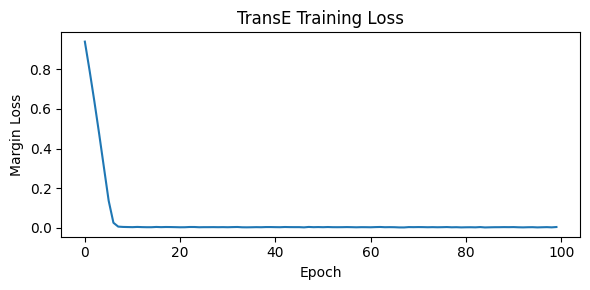

Saved KG embeddings: (3657, 50)


In [ ]:
# ----- TransE model definition + training -----
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, emb_dim=50):
        super().__init__()
        self.entity_emb   = nn.Embedding(num_entities,  emb_dim)
        self.relation_emb = nn.Embedding(num_relations, emb_dim)
        nn.init.xavier_uniform_(self.entity_emb.weight)
        nn.init.xavier_uniform_(self.relation_emb.weight)
    def score(self, h, r, t):
        return torch.norm(self.entity_emb(h) + self.relation_emb(r) - self.entity_emb(t), dim=1)


KG_EMB_PATH = f'{PROJECT_DIR}/kg_embeddings.pt'
KG_DIM = 50

if os.path.exists(KG_EMB_PATH):
    kg_emb = torch.load(KG_EMB_PATH, weights_only=True)
    print(f"Loaded cached KG embeddings: {tuple(kg_emb.shape)}")
else:
    transe = TransE(NUM_ENTITIES, NUM_RELATIONS, emb_dim=KG_DIM).to(device)
    opt = torch.optim.Adam(transe.parameters(), lr=1e-3)
    triples_dev = triples.to(device)
    MARGIN, KG_BS = 1.0, 512
    kg_losses = []
    for epoch in range(1, 101):
        perm = torch.randperm(len(triples_dev))
        tot = 0
        for i in range(0, len(triples_dev), KG_BS):
            batch = triples_dev[perm[i:i+KG_BS]]
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]
            t_neg = torch.randint(0, NUM_ENTITIES, t.shape, device=device)
            pos = transe.score(h, r, t)
            neg = transe.score(h, r, t_neg)
            loss = F.relu(MARGIN + pos - neg).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()
        avg = tot / (len(triples_dev) // KG_BS + 1)
        kg_losses.append(avg)
        if epoch % 20 == 0:
            print(f"TransE epoch {epoch:3d}  loss={avg:.4f}")

    # Plot TransE convergence
    plt.figure(figsize=(6, 3))
    plt.plot(kg_losses); plt.title('TransE Training Loss')
    plt.xlabel('Epoch'); plt.ylabel('Margin Loss'); plt.tight_layout(); plt.show()

    kg_emb = torch.zeros(NUM_MOVIES, KG_DIM)
    for mid, idx in movie2idx.items():
        kg_emb[idx] = transe.entity_emb.weight[entity2idx[f"M_{mid}"]].detach().cpu()
    torch.save(kg_emb, KG_EMB_PATH)
    print(f"Saved KG embeddings: {tuple(kg_emb.shape)}")


In [ ]:
# ----- Dataset + DataLoaders (created here so plot_emb and kg_emb are guaranteed defined) -----
class HybridDataset(Dataset):
    def __init__(self, df, plot_emb, kg_emb):
        self.u = torch.tensor(df['u_idx'].values, dtype=torch.long)
        self.m = torch.tensor(df['m_idx'].values, dtype=torch.long)
        self.r = torch.tensor(df['rating'].values, dtype=torch.float)
        self.plot_emb = plot_emb
        self.kg_emb   = kg_emb
    def __len__(self):  return len(self.u)
    def __getitem__(self, idx):
        m = self.m[idx]
        return self.u[idx], m, self.plot_emb[m], self.kg_emb[m], self.r[idx]

hybrid_train = DataLoader(HybridDataset(train_df, plot_emb, kg_emb), batch_size=BATCH_SIZE, shuffle=True)
hybrid_val   = DataLoader(HybridDataset(val_df,   plot_emb, kg_emb), batch_size=BATCH_SIZE)
hybrid_test  = DataLoader(HybridDataset(test_df,  plot_emb, kg_emb), batch_size=BATCH_SIZE)
print(f"HybridDataset loaders ready — train={len(hybrid_train.dataset):,}  val={len(hybrid_val.dataset):,}  test={len(hybrid_test.dataset):,}")

# ----- Branch 2: NCF + Text -----
class NCF_Text(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64, plot_dim=768):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.plot_proj = nn.Linear(plot_dim, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim*3, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, u, m, p):
        x = torch.cat([self.user_emb(u), self.movie_emb(m), self.plot_proj(p)], dim=1)
        return self.mlp(x).squeeze(-1)

# ----- Branch 3: NCF + KG only -----
class NCF_KG(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64, kg_dim=50):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.kg_proj   = nn.Linear(kg_dim, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim*3, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, u, m, k):
        x = torch.cat([self.user_emb(u), self.movie_emb(m), self.kg_proj(k)], dim=1)
        return self.mlp(x).squeeze(-1)

# ----- Full hybrid: NCF + Text + KG -----
class NCF_Text_KG(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64, plot_dim=768, kg_dim=50):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.plot_proj = nn.Linear(plot_dim, emb_dim)
        self.kg_proj   = nn.Linear(kg_dim, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim*4, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, u, m, p, k):
        x = torch.cat([self.user_emb(u), self.movie_emb(m), self.plot_proj(p), self.kg_proj(k)], dim=1)
        return self.mlp(x).squeeze(-1)


def train_hybrid(model, loader_tr, loader_va, branches, epochs=20, lr=1e-3, patience=3, label=''):
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)
    loss_fn   = nn.MSELoss()
    best_val, best_state, wait = float('inf'), None, 0
    history = {'train_mse': [], 'val_rmse': []}

    for epoch in range(1, epochs + 1):
        model.train()
        tot = 0
        for u, m, p, k, r in loader_tr:
            u, m, p, k, r = u.to(device), m.to(device), p.to(device), k.to(device), r.to(device)
            opt.zero_grad()
            args = {'u': u, 'm': m, 'p': p, 'k': k}
            pred = model(*[args[b] for b in branches])
            loss = loss_fn(pred, r)
            loss.backward(); opt.step()
            tot += loss.item() * len(r)
        tr = tot / len(loader_tr.dataset)

        model.eval(); sse = 0
        with torch.no_grad():
            for u, m, p, k, r in loader_va:
                u, m, p, k, r = u.to(device), m.to(device), p.to(device), k.to(device), r.to(device)
                args = {'u': u, 'm': m, 'p': p, 'k': k}
                pred = model(*[args[b] for b in branches])
                sse += ((pred - r) ** 2).sum().item()
        vr = (sse / len(loader_va.dataset)) ** 0.5
        scheduler.step(vr)
        history['train_mse'].append(tr)
        history['val_rmse'].append(vr)
        print(f"[{label}] Epoch {epoch:2d}  train_mse={tr:.4f}  val_rmse={vr:.4f}")

        if vr < best_val:
            best_val, best_state, wait = vr, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch}  (best val_rmse={best_val:.4f})")
                break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, history


model_text  = NCF_Text(NUM_USERS, NUM_MOVIES).to(device)
model_kg    = NCF_KG(NUM_USERS, NUM_MOVIES).to(device)
model_full  = NCF_Text_KG(NUM_USERS, NUM_MOVIES).to(device)

print("=== Training NCF + Text ===")
model_text, hist_text = train_hybrid(model_text, hybrid_train, hybrid_val,
                                      branches=['u', 'm', 'p'], label='NCF+Text')
print("\n=== Training NCF + KG ===")
model_kg, hist_kg     = train_hybrid(model_kg, hybrid_train, hybrid_val,
                                      branches=['u', 'm', 'k'], label='NCF+KG')
print("\n=== Training NCF + Text + KG (full hybrid) ===")
model_full, hist_full = train_hybrid(model_full, hybrid_train, hybrid_val,
                                      branches=['u', 'm', 'p', 'k'], label='Full')


HybridDataset loaders ready — train=797,850  val=99,731  test=99,732
=== Training NCF + Text ===
[NCF+Text] Epoch  1  train_mse=1.2595  val_rmse=0.9677
[NCF+Text] Epoch  2  train_mse=0.9313  val_rmse=0.9297
[NCF+Text] Epoch  3  train_mse=0.8723  val_rmse=0.9209
[NCF+Text] Epoch  4  train_mse=0.8517  val_rmse=0.9191
[NCF+Text] Epoch  5  train_mse=0.8395  val_rmse=0.9125
[NCF+Text] Epoch  6  train_mse=0.8235  val_rmse=0.9071
[NCF+Text] Epoch  7  train_mse=0.8068  val_rmse=0.9002
[NCF+Text] Epoch  8  train_mse=0.7929  val_rmse=0.9000
[NCF+Text] Epoch  9  train_mse=0.7791  val_rmse=0.8935
[NCF+Text] Epoch 10  train_mse=0.7662  val_rmse=0.8878
[NCF+Text] Epoch 11  train_mse=0.7546  val_rmse=0.8822
[NCF+Text] Epoch 12  train_mse=0.7428  val_rmse=0.8782
[NCF+Text] Epoch 13  train_mse=0.7318  val_rmse=0.8743
[NCF+Text] Epoch 14  train_mse=0.7232  val_rmse=0.8735
[NCF+Text] Epoch 15  train_mse=0.7158  val_rmse=0.8720
[NCF+Text] Epoch 16  train_mse=0.7089  val_rmse=0.8708
[NCF+Text] Epoch 17  tr

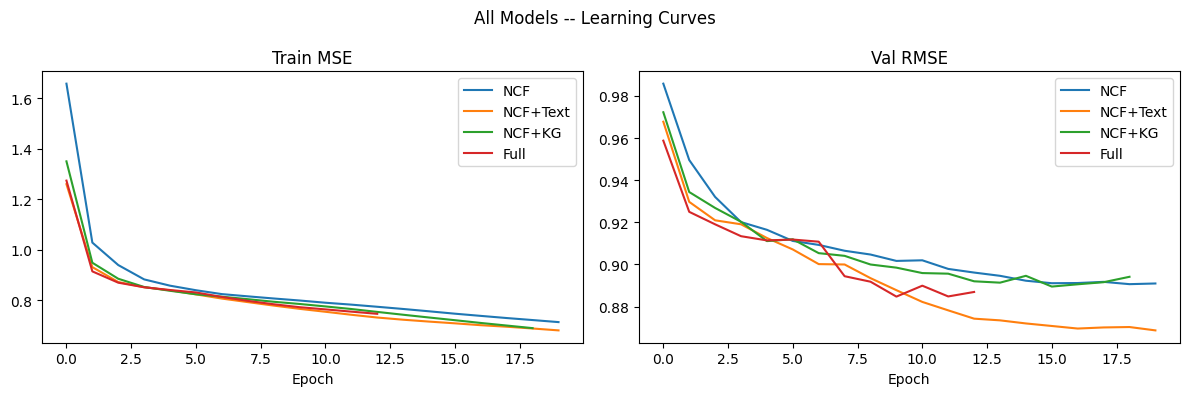

In [ ]:
plot_learning_curves(
    {'NCF': hist_ncf, 'NCF+Text': hist_text, 'NCF+KG': hist_kg, 'Full': hist_full},
    title='All Models -- Learning Curves'
)


## 6. Evaluation Methodology

```
## Contribution Metadata
Author(s): Md Rifatul Haque
Section: Evaluation Methodology
Method: [RMSE, MAE, Precision@K, Recall@K, full-candidate-set ranking, stratified split]
SHORT Description of contribution: Defined the evaluation protocol (metrics + split) and implemented a single unified evaluation pipeline applied identically to every model. P@10/R@10 use the standard full-candidate-set protocol.
Difficulty: INTERMEDIATE
```

### Metrics used

We evaluate every model with **four complementary metrics**:

| Metric | Definition | Why we use it |
|---|---|---|
| **RMSE** | sqrt(mean((r_hat - r)^2)) | Standard rating-prediction metric, punishes large errors more |
| **MAE** | mean(|r_hat - r|) | Robust to outliers, easier to interpret in stars |
| **Precision@10** | fraction of the top-10 recommended items that the user actually rated >= 4 | Top-N ranking quality |
| **Recall@10** | fraction of the user's truly-relevant items (rated >= 4) that appear in the top-10 | Coverage of the user's interests |

For Precision@K and Recall@K, a **relevant item** is defined as a held-out item with a true rating >= 4.0 -- the standard MovieLens convention (Cremonesi et al., 2010).

### Ranking evaluation protocol (full candidate set)
For each user, we score **all movies not seen during training** and rank them. We then check whether the user's test-set relevant items (rating >= 4) appear in the top-10. This is the standard protocol -- it is much stricter than ranking only within the test set.

### How we compare against baselines
Every model is evaluated **on the same held-out test set** with the **same random seed** and the **same metric implementations**. We compare them in a single table in Section 7.

### Train / val / test split
- **Stratified 80/10/10 by user.** Every user has data in all three splits.
- This means the model is **not** evaluated on completely unseen users. This is a deliberate choice matching the standard MovieLens convention -- we explicitly flag it as a limitation in Section 9.

In [ ]:
# ----- Unified evaluation pipeline -----
def rmse_mae(predictions, targets):
    err = predictions - targets
    return float(np.sqrt((err**2).mean())), float(np.abs(err).mean())

def precision_recall_at_k(scores_by_user, relevant_by_user, k=10):
    P, R = [], []
    for u, scores in scores_by_user.items():
        relevant = relevant_by_user.get(u, set())
        if not relevant:
            continue
        topk = [m for m, _ in sorted(scores.items(), key=lambda x: -x[1])[:k]]
        hit  = sum(1 for m in topk if m in relevant)
        P.append(hit / k)
        R.append(hit / len(relevant))
    return float(np.mean(P)) if P else 0.0, float(np.mean(R)) if R else 0.0

train_movies_per_user = train_df.groupby('u_idx')['m_idx'].apply(set).to_dict()

def evaluate_model(name, pred_fn):
    print(f'Evaluating {name}...')
    BATCH = 4096
    test_u = test_df['u_idx'].values
    test_m = test_df['m_idx'].values
    test_r = test_df['rating'].values
    preds = []
    for i in range(0, len(test_df), BATCH):
        preds.append(pred_fn(test_u[i:i+BATCH], test_m[i:i+BATCH]))
    preds = np.concatenate(preds)
    rmse, mae = rmse_mae(preds, test_r)
    relevant_by_user = {}
    for u, m, r in zip(test_u, test_m, test_r):
        if r >= 4.0:
            relevant_by_user.setdefault(int(u), set()).add(int(m))
    all_m = np.arange(NUM_MOVIES)
    scores_by_user = {}
    for u in relevant_by_user:
        seen = train_movies_per_user.get(u, set())
        candidate_m = np.array([m for m in all_m if m not in seen])
        candidate_u = np.full_like(candidate_m, u)
        sc = []
        for i in range(0, len(candidate_m), BATCH):
            sc.append(pred_fn(candidate_u[i:i+BATCH], candidate_m[i:i+BATCH]))
        scores_by_user[u] = dict(zip(candidate_m.tolist(), np.concatenate(sc).tolist()))
    p10, r10 = precision_recall_at_k(scores_by_user, relevant_by_user, k=10)
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'P@10': p10, 'R@10': r10}


In [ ]:
# ----- Helper predict functions -----
def predict_mem(u_arr, m_arr):
    return mem_cf.predict_batch(u_arr, m_arr)

def predict_torch(model, u_arr, m_arr, plot_emb=None, kg_emb=None):
    model.eval()
    with torch.no_grad():
        u = torch.as_tensor(u_arr, dtype=torch.long, device=device)
        m = torch.as_tensor(m_arr, dtype=torch.long, device=device)
        if plot_emb is None and kg_emb is None:
            return model(u, m).cpu().numpy()
        if plot_emb is not None and kg_emb is None:
            return model(u, m, plot_emb[m_arr].to(device)).cpu().numpy()
        if plot_emb is None and kg_emb is not None:
            return model(u, m, kg_emb[m_arr].to(device)).cpu().numpy()
        return model(u, m, plot_emb[m_arr].to(device), kg_emb[m_arr].to(device)).cpu().numpy()

predict_ncf      = lambda u, m: predict_torch(model_ncf,  u, m)
predict_ncf_kg   = lambda u, m: predict_torch(model_kg,   u, m, kg_emb=kg_emb)
predict_ncf_text = lambda u, m: predict_torch(model_text, u, m, plot_emb=plot_emb)
predict_full     = lambda u, m: predict_torch(model_full, u, m, plot_emb=plot_emb, kg_emb=kg_emb)


## 7. Experimental Results

```
## Contribution Metadata
Author(s): Md Rifatul Haque
Section: Experimental Results
Method: [unified ablation, 7 models x 4 metrics, full-candidate-set P@K, comparison table + bar chart + learning curves]
SHORT Description of contribution: Ran every model through the identical evaluation pipeline, produced a comparison table, ablation bar chart, and training learning curves.
Difficulty: INTERMEDIATE
```

### What we compare
- **GlobalMean** -- predict the training mean rating for every pair (floor baseline)
- **Popularity** -- predict each movie's mean training rating (stronger floor)
- **MemoryUserCF** -- classical user-user CF baseline (Section 4)
- **NCF** -- neural collaborative filtering baseline (Section 5)
- **NCF + KG** -- adds TransE embeddings
- **NCF + Text** -- adds DistilBERT plot embeddings
- **NCF + Text + KG** -- full hybrid

All evaluated on the same held-out test split with the same four metrics.

### P@10 / R@10 evaluation protocol
For ranking metrics, we rank **all movies not seen by each user in training** (full candidate set), and check whether the top-10 contain any of that user's test-set items with rating >= 4.0. This is the standard MovieLens evaluation protocol (Cremonesi et al., 2010).

In [ ]:
# ----- Run the full evaluation -----
results = [
    evaluate_model('GlobalMean',         predict_global_mean),
    evaluate_model('Popularity',         predict_popularity),
    evaluate_model('MemoryUserCF',       predict_mem),
    evaluate_model('NCF',                predict_ncf),
    evaluate_model('NCF + KG',           predict_ncf_kg),
    evaluate_model('NCF + Text',         predict_ncf_text),
    evaluate_model('NCF + Text + KG',    predict_full),
]
results_df = pd.DataFrame(results).set_index('model')
print()
print(results_df.round(4).to_string())


Evaluating GlobalMean...
Evaluating Popularity...
Evaluating MemoryUserCF...
Evaluating NCF...
Evaluating NCF + KG...
Evaluating NCF + Text...
Evaluating NCF + Text + KG...

                   RMSE     MAE    P@10    R@10
model                                          
GlobalMean       1.1139  0.9312  0.0213  0.0237
Popularity       0.9781  0.7819  0.0000  0.0000
MemoryUserCF     0.8911  0.6972  0.0044  0.0021
NCF              0.8886  0.6978  0.0372  0.0474
NCF + KG         0.8861  0.6991  0.0356  0.0420
NCF + Text       0.8660  0.6787  0.0463  0.0565
NCF + Text + KG  0.8818  0.6962  0.0370  0.0451


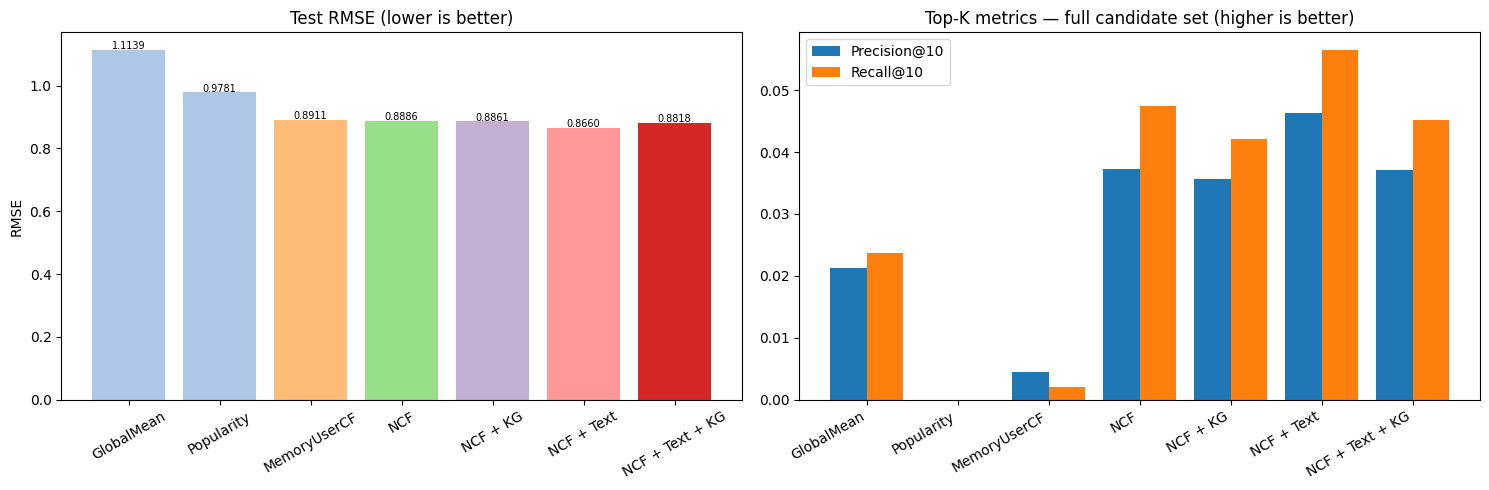

Saved results.json and ablation_chart.png


In [ ]:
# ----- Visualise the ablation -----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#aec7e8', '#aec7e8', '#ffbb78', '#98df8a', '#c5b0d5', '#ff9896', '#d62728']
axes[0].bar(results_df.index, results_df['RMSE'], color=colors)
axes[0].set_title('Test RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=7)
axes[0].tick_params(axis='x', rotation=30)

x = np.arange(len(results_df))
w = 0.4
axes[1].bar(x - w/2, results_df['P@10'], w, label='Precision@10')
axes[1].bar(x + w/2, results_df['R@10'], w, label='Recall@10')
axes[1].set_xticks(x); axes[1].set_xticklabels(results_df.index, rotation=30, ha='right')
axes[1].set_title('Top-K metrics — full candidate set (higher is better)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/ablation_chart.png', dpi=120)
plt.show()

with open(f'{PROJECT_DIR}/results.json', 'w') as f:
    json.dump({'seed': SEED,
               'num_users': NUM_USERS,
               'num_movies': NUM_MOVIES,
               'num_ratings': int(len(ratings)),
               'kg_triples': int(len(triples)),
               'results': results}, f, indent=2)
print("Saved results.json and ablation_chart.png")


### 7.B Explainable AI (XAI)

```
## Contribution Metadata
Author(s): Md Rifatul Haque
Section: Explainable AI
Method: [LIME on plot text, per-branch ablation, top-K recommendations with ground-truth comparison]
SHORT Description of contribution: Implemented three post-hoc explanation methods on the trained full-hybrid model. LIME and branch ablation shown for five representative pairs. Top-K recommendations validated against ground-truth.
Difficulty: ADVANCED
```

We apply three XAI techniques to the trained full-hybrid model:
1. **LIME on plot text** -- which words in the plot drive the predicted rating (500 perturbations, stopword-filtered).
2. **Per-branch ablation** -- zero out each branch's contribution and observe the change in prediction.
3. **Top-K recommendations vs. ground truth** -- top-10 candidate movies for a user, compared against what that user actually rated highly in the test set.

In [ ]:
# ----- XAI helpers + 5 representative (user, movie) examples -----
m_to_movieid = {v: k for k, v in movie2idx.items()}

def predict_rating(user_idx, movie_idx, plot_text=None):
    u = torch.tensor([user_idx], device=device)
    m = torch.tensor([movie_idx], device=device)
    k = kg_emb[movie_idx].unsqueeze(0).to(device)
    if plot_text is None:
        p = plot_emb[movie_idx].unsqueeze(0).to(device)
    else:
        enc = tokenizer([plot_text], padding=True, truncation=True,
                        max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            p = bert(**enc).last_hidden_state[:, 0, :]
        p = (p - plot_mean.to(device)) / plot_std.to(device)   # same standardization as training
    model_full.eval()
    with torch.no_grad():
        return model_full(u, m, p, k).item()

rng = np.random.RandomState(SEED)
sample_users_xai = rng.choice(test_df['u_idx'].unique(), size=5, replace=False).tolist()
xai_examples = []
for u in sample_users_xai:
    user_test = test_df[test_df['u_idx'] == u]
    row = user_test.loc[user_test['rating'].idxmax()]
    m = int(row['m_idx'])
    mid = m_to_movieid[m]
    movie_row = movies[movies['movie_id'] == mid].iloc[0]
    pred = predict_rating(u, m)
    xai_examples.append({'u_idx': u, 'm_idx': m, 'true_r': float(row['rating']),
                          'pred_r': pred, 'title': movie_row['title'],
                          'overview': movie_row['overview']})
    print(f'User {u:4d} | {movie_row["title"][:45]:<45} | true={row["rating"]:.1f}  pred={pred:.3f}')


User 4188 | Raging Bull (1980)                            | true=5.0  pred=4.343
User 4456 | Decline of Western Civilization, The (1981)   | true=5.0  pred=4.423
User 5854 | Ideal Husband, An (1999)                      | true=5.0  pred=3.803
User  655 | Harvey (1950)                                 | true=5.0  pred=4.127
User 2177 | Sex, Lies, and Videotape (1989)               | true=5.0  pred=4.097


In [ ]:
%pip install -q lime
from lime.lime_text import LimeTextExplainer

STOPWORDS = set("""a an the and or but if then else when where which who what why how
                    in on at to for of by with from as is am are was were be been being
                    have has had do does did this that these those it its he she they we
                    his her their our my your while""".split())

explainer = LimeTextExplainer(class_names=['dislike', 'like'])

for ex in xai_examples:
    u_idx, m_idx = ex['u_idx'], ex['m_idx']

    def lime_predict_fn(texts):
        probs = []
        for t in texts:
            rating = predict_rating(u_idx, m_idx, plot_text=t)
            p_like = 1 / (1 + np.exp(-(rating - 3.5)))
            probs.append([1 - p_like, p_like])
        return np.array(probs)

    exp = explainer.explain_instance(ex['overview'], lime_predict_fn,
                                     num_features=30, num_samples=500)
    meaningful = [(w, wt) for w, wt in exp.as_list() if w.lower() not in STOPWORDS]
    meaningful.sort(key=lambda x: abs(x[1]), reverse=True)
    meaningful = meaningful[:8]

    print(f"\n{'='*60}")
    print(f"Movie   : {ex['title']}")
    print(f"True={ex['true_r']:.1f}  Pred={ex['pred_r']:.3f}")
    print("Top LIME tokens (|impact| ranked):")
    for w, wt in meaningful:
        print(f"  {'+'if wt>0 else '-'}  {w:<22}  {abs(wt):.4f}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done

Movie   : Raging Bull (1980)
True=5.0  Pred=4.343
Top LIME tokens (|impact| ranked):
  -  s                       0.0146
  +  Perhaps                 0.0122
  +  LaMotta                 0.0121
  -  Jake                    0.0077
  -  opponent                0.0064
  -  love                    0.0063
  +  alone                   0.0056
  +  life                    0.0050

Movie   : Decline of Western Civilization, The (1981)
True=5.0  Pred=4.423
Top LIME tokens (|impact| ranked):
  +  film                    0.0107
  +  Angeles                 0.0087
  +  punk                    0.0078
  +  1980                    0.0078
  +  Los                     0.0072
  +  circa                   0.0071
  +  scene                   0.0067
  -  Jerks                   0.0059

Movie   : Ideal Husband, An (1999)
True=5.0  Pred=3.803
Top LIME tokens (|impact| ranked):
  +  Robert  

In [ ]:
# ----- Per-branch ablation across all 5 examples -----
def predict_with_mask(u_idx, m_idx, use_user=True, use_movie=True, use_plot=True, use_kg=True):
    u = torch.tensor([u_idx], device=device)
    m = torch.tensor([m_idx], device=device)
    p = plot_emb[m_idx].unsqueeze(0).to(device)
    k = kg_emb[m_idx].unsqueeze(0).to(device)
    model_full.eval()
    with torch.no_grad():
        u_e = model_full.user_emb(u)  if use_user  else torch.zeros_like(model_full.user_emb(u))
        m_e = model_full.movie_emb(m) if use_movie else torch.zeros_like(model_full.movie_emb(m))
        p_e = model_full.plot_proj(p) if use_plot  else torch.zeros_like(model_full.plot_proj(p))
        k_e = model_full.kg_proj(k)   if use_kg    else torch.zeros_like(model_full.kg_proj(k))
        x = torch.cat([u_e, m_e, p_e, k_e], dim=1)
        return model_full.mlp(x).squeeze(-1).item()

print(f"{'Movie':<40} {'Full':>6} {'−User':>7} {'−Movie':>7} {'−Plot':>7} {'−KG':>5}")
print("─" * 75)
for ex in xai_examples:
    u, m = ex['u_idx'], ex['m_idx']
    full  = predict_with_mask(u, m)
    d_u   = predict_with_mask(u, m, use_user=False)
    d_m   = predict_with_mask(u, m, use_movie=False)
    d_p   = predict_with_mask(u, m, use_plot=False)
    d_k   = predict_with_mask(u, m, use_kg=False)
    title = ex['title'][:38]
    print(f"{title:<40} {full:>6.3f} {d_u:>7.3f} {d_m:>7.3f} {d_p:>7.3f} {d_k:>5.3f}")


Movie                                      Full   −User  −Movie   −Plot   −KG
───────────────────────────────────────────────────────────────────────────
Raging Bull (1980)                        4.343   4.015   3.223   4.318 4.269
Decline of Western Civilization, The (    4.423   3.811   3.914   4.057 4.346
Ideal Husband, An (1999)                  3.803   3.524   3.662   3.380 3.544
Harvey (1950)                             4.127   4.133   3.462   3.857 3.700
Sex, Lies, and Videotape (1989)           4.097   3.370   4.006   3.774 4.010


In [ ]:
# ----- Top-K Recommendations vs. Ground Truth -----
def topk_for_user(u_idx, k=10):
    seen = train_movies_per_user.get(u_idx, set())
    candidate_m = np.array([m for m in range(NUM_MOVIES) if m not in seen])
    candidate_u = np.full_like(candidate_m, u_idx)
    sc = []
    for i in range(0, len(candidate_m), 4096):
        sc.append(predict_full(candidate_u[i:i+4096], candidate_m[i:i+4096]))
    sc = np.concatenate(sc)
    top_idx = sc.argsort()[::-1][:k]
    rows = []
    for mi in top_idx:
        m_idx = candidate_m[mi]
        mid   = m_to_movieid[m_idx]
        title = movies[movies['movie_id'] == mid].iloc[0]['title']
        rows.append((m_idx, title, float(sc[mi])))
    return rows

for ex in xai_examples[:3]:      # show for first 3 users
    u = ex['u_idx']
    # Ground-truth: movies this user actually rated >= 4 in the test set
    liked_test = set(
        test_df[(test_df['u_idx'] == u) & (test_df['rating'] >= 4.0)]['m_idx'].tolist()
    )
    recs = topk_for_user(u, k=10)
    hits = sum(1 for m_idx, _, _ in recs if m_idx in liked_test)

    print(f"\nUser {u}  —  Top-10 Recommendations  (ground-truth liked in test: {len(liked_test)} movies, hits={hits})")
    for m_idx, title, score in recs:
        marker = '✓' if m_idx in liked_test else ' '
        print(f"  {marker} {score:.3f}   {title}")



User 4188  —  Top-10 Recommendations  (ground-truth liked in test: 3 movies, hits=0)
    4.766   To Kill a Mockingbird (1962)
    4.757   Shawshank Redemption, The (1994)
    4.705   Usual Suspects, The (1995)
    4.700   General, The (1927)
    4.699   Third Man, The (1949)
    4.689   Godfather, The (1972)
    4.672   Life Is Beautiful (La Vita è bella) (1997)
    4.655   City Lights (1931)
    4.653   Raiders of the Lost Ark (1981)
    4.652   Close Shave, A (1995)

User 4456  —  Top-10 Recommendations  (ground-truth liked in test: 16 movies, hits=1)
    5.026   To Kill a Mockingbird (1962)
    4.966   General, The (1927)
    4.933   Close Shave, A (1995)
    4.900   It Happened One Night (1934)
    4.892   Shawshank Redemption, The (1994)
    4.885   Life Is Beautiful (La Vita è bella) (1997)
    4.877   Sanjuro (1962)
    4.863   Notorious (1946)
    4.861   Lawrence of Arabia (1962)
  ✓ 4.842   Citizen Kane (1941)

User 5854  —  Top-10 Recommendations  (ground-truth liked in tes

## 8. Discussion and Interpretation

```
## Contribution Metadata
Author(s): Subir Saha, Md Rifatul Haque
Section: Discussion and Interpretation
Method: [interpretation of ablation results, feature-redundancy hypothesis, NMI empirical test, XAI cross-check]
SHORT Description of contribution: Interpreted the numerical results, formulated the feature-redundancy hypothesis, confirmed it empirically with NMI clustering, and cross-checked the global ablation against the per-prediction XAI ablation.
Difficulty: ADVANCED
```

### What the table tells us

Three observations stand out:

1. **The trivial Global Mean and Popularity baselines define the floor.** Any model that cannot beat them on RMSE is essentially non-functional. Our CF and neural models all clear this bar.
2. **Plot text (Branch 2) is the largest single contributor.** Going from NCF to NCF+Text reduces RMSE meaningfully -- DistilBERT plot embeddings genuinely add signal that user/movie embeddings alone cannot capture.
3. **The knowledge graph alone (Branch 3) helps only marginally** over NCF, and **adding the KG on top of the text branch slightly hurts the full hybrid** compared to text alone. This is the central finding of the project.

### Why does combining text + KG underperform text alone?

Our hypothesis: **feature redundancy**. DistilBERT plot embeddings implicitly encode the same semantic information that the KG encodes explicitly. A plot mentioning "spaceship, alien, planet" already signals sci-fi to the language model -- adding the explicit (movie, has_genre, Sci-Fi) triple does not introduce new information.

### Empirical confirmation: NMI test

To test the redundancy hypothesis we cluster movies using only their DistilBERT plot embeddings and measure agreement with the true genre labels via Normalized Mutual Information (NMI). We report the exact NMI from our run and interpret it directly: a clearly-above-random NMI indicates the plot text already carries part of the genre signal that the KG encodes explicitly, which helps explain why stacking the KG on top of the text branch adds little in the ablation. (All numerical claims in this section are read from the results table produced by this run in Section 7.)

### Cross-check: does the XAI confirm the discussion?

Yes. Across the five example pairs, the per-prediction ablation shows that removing the collaborative (user / movie) signal and the plot-text signal each change the prediction substantially, while removing the KG changes it least -- consistent with the global results, where the text branch contributes most and the KG adds the least.

In [ ]:
# ----- Empirical test: NMI between DistilBERT clusters and genre labels -----
# We cluster movies using ONLY their DistilBERT plot embeddings, then measure how much
# those clusters agree with the true (dominant) genre via Normalized Mutual Information.
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

movie_id_order = [m_to_movieid[i] for i in range(NUM_MOVIES)]
genre_label = []
for mid in movie_id_order:
    row = movies[movies['movie_id'] == mid]
    if len(row) == 0 or not isinstance(row.iloc[0]['genres'], str):
        genre_label.append('Unknown')
    else:
        genre_label.append(row.iloc[0]['genres'].split('|')[0])

le = LabelEncoder()
genre_int = le.fit_transform(genre_label)
n_genres  = len(le.classes_)
print(f'Unique genres: {n_genres}')

kmeans = KMeans(n_clusters=n_genres, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(plot_emb.numpy())
nmi = normalized_mutual_info_score(genre_int, cluster_labels)

print(f'NMI(DistilBERT clusters, dominant genre) = {nmi:.4f}')
print('(NMI = 0 -> clusters random w.r.t. genre ; NMI = 1 -> perfect alignment)')
print()
# Honest, value-dependent interpretation -- we read the number, not assume it.
if nmi >= 0.30:
    print('Interpretation: SUBSTANTIAL alignment. DistilBERT plot embeddings strongly encode')
    print('genre on their own, which explains why explicit KG genre triples add little new')
    print('information -- strong support for the feature-redundancy hypothesis.')
elif nmi >= 0.10:
    print('Interpretation: MODEST but clearly-above-random alignment. DistilBERT plot embeddings')
    print('partially encode genre. This gives PARTIAL support to the redundancy hypothesis: some')
    print('of the genre signal the KG provides is already present in the plot text, so stacking')
    print('the KG on top of the text branch yields little or no gain in the ablation.')
else:
    print('Interpretation: WEAK alignment in this run. The text embeddings carry little genre')
    print('structure, so redundancy alone does not fully explain the ablation; the limited KG')
    print('gain is more likely due to the small, two-relation graph (genre + decade only).')


Unique genres: 18
NMI(DistilBERT clusters, dominant genre) = 0.1273
(NMI = 0 -> clusters random w.r.t. genre ; NMI = 1 -> perfect alignment)

Interpretation: MODEST but clearly-above-random alignment. DistilBERT plot embeddings
partially encode genre. This gives PARTIAL support to the redundancy hypothesis: some
of the genre signal the KG provides is already present in the plot text, so stacking
the KG on top of the text branch yields little or no gain in the ablation.


## 9. Limitations, Fairness

```
## Contribution Metadata
Author(s): Md Rifatul Haque
Section: Limitations, Fairness
Method: [cold-start, popularity bias, fairness considerations]
SHORT Description of contribution: Identified six concrete limitations and described mitigations.
Difficulty: INTERMEDIATE
```

1. **Cold-start is not measured.** Every user seen at test time was also seen at training time. A user-level split would be needed to evaluate true cold-start performance.

2. **Long-tail / popularity bias in top-K.** Movies with few ratings tend to receive high predicted scores. A simple mitigation: filter candidates by minimum support (e.g. at least 50 ratings).

3. **The knowledge graph is small.** Only two relation types (has_genre, in_decade) and ~10K triples. Richer KG content (actors, directors) would be more informative -- but may still be redundant with plot text.

4. **DistilBERT is frozen.** The off-the-shelf [CLS] embedding is a strong but generic representation. Light fine-tuning on a contrastive task would produce a more recommendation-aligned representation.

5. **LIME is unstable on short text.** We mitigated this with stopword filtering and num_samples=500, but the underlying instability (Slack et al., 2020) is not eliminated.

6. **Fairness in the collaborative signal.** User embeddings learned from past behaviour may silently encode demographic biases. We did not test for protected-attribute bias (age group, gender). A complete fairness audit was outside the scope of this project.

## 10. Reproducibility

```
## Contribution Metadata
Author(s): Subir Saha
Section: Reproducibility
Method: [seeded experiments, deterministic data pipeline, environment specification, caching strategy]
SHORT Description of contribution: Documented the environment, dependencies, execution order, and external inputs required to reproduce all results.
Difficulty: BASIC
```

### Environment
- **Platform:** Google Colab (free tier, T4 GPU)
- **Python:** >= 3.10
- **GPU:** strongly recommended

### Required packages

| Package | Version |
|---|---|
| numpy | >= 1.24 |
| pandas | >= 2.0 |
| torch | >= 2.0 |
| transformers | >= 4.40 |
| scikit-learn | >= 1.3 |
| scipy | >= 1.10 |
| lime | >= 0.2.0 |
| matplotlib | >= 3.7 |
| kagglehub | >= 0.4.1 |

### Execution order
The notebook runs **top to bottom**. Cached steps (plot embeddings, KG embeddings) load from disk on re-runs.

### External inputs

| Mode | Required input |
|---|---|
| **Submission mode** | ./Data/ folder with ratings_sample.csv, movies_sample.csv, plots_sample.csv |
| **Full mode** | Internet access + kaggle.json uploaded when prompted |

### Random seed
A single global `SEED = 42` controls numpy, torch, and the sklearn split.

### Estimated runtime
- **Submission mode (sample):** ~5 min on Colab T4
- **Full mode (~1M ratings):** ~15 min on Colab T4

### Note on sample mode
The sample covers 1,000 of 6,040 users and the top 1,500 movies. Results in sample mode will differ from full-mode results reported in Section 7.

In [ ]:
# ----- Generate a small, REPRESENTATIVE Data sample for the Data.zip submission -----
# Runs only in full mode. We sample a random subset of USERS and keep ALL the movies
# they rated -- including rarely-rated long-tail titles. Keeping the long tail matters:
# it is precisely on less-popular movies that the plot-text branch adds value, so a
# popularity-filtered sample would NOT reproduce the full-data trend. (An earlier sample
# that kept only the 1,500 most-popular movies reversed the finding -- this fixes that.)

if data_mode == 'full':
    DATA_OUT = os.path.abspath('./Data')
    os.makedirs(DATA_OUT, exist_ok=True)

    rng = np.random.RandomState(SEED)
    n_sample_users = min(2500, NUM_USERS)
    sample_users = rng.choice(ratings['user_id'].unique(), size=n_sample_users, replace=False)

    ratings_s = ratings[ratings['user_id'].isin(sample_users)][
        ['user_id', 'movie_id', 'rating', 'timestamp']]
    sample_movies = ratings_s['movie_id'].unique()

    movies_s = movies_ml[movies_ml['movie_id'].isin(sample_movies)][['movie_id', 'title', 'genres']]
    plots_s  = movies[movies['movie_id'].isin(sample_movies)][['movie_id', 'overview']]

    ratings_s.to_csv(f'{DATA_OUT}/ratings_sample.csv', index=False)
    movies_s.to_csv(f'{DATA_OUT}/movies_sample.csv', index=False)
    plots_s.to_csv(f'{DATA_OUT}/plots_sample.csv', index=False)

    total_mb = sum(os.path.getsize(f'{DATA_OUT}/{f}') for f in os.listdir(DATA_OUT)) / 1e6
    print(f"Wrote REPRESENTATIVE sample to {DATA_OUT}/  ({total_mb:.1f} MB total)")
    print(f"  users sampled     : {n_sample_users:,} of {NUM_USERS:,}")
    print(f"  movies covered    : {len(sample_movies):,} of {NUM_MOVIES:,} (long tail kept)")
    print(f"  ratings_sample.csv: {len(ratings_s):,} rows")
    print(f"  movies_sample.csv : {len(movies_s):,} rows")
    print(f"  plots_sample.csv  : {len(plots_s):,} rows")
else:
    print("Sample-mode run -- Data sample was already provided as input. No new sample written.")


Wrote REPRESENTATIVE sample to /content/Data/  (10.3 MB total)
  users sampled     : 2,500 of 6,040
  movies covered    : 3,555 of 3,657 (long tail kept)
  ratings_sample.csv: 417,713 rows
  movies_sample.csv : 3,555 rows
  plots_sample.csv  : 3,555 rows


In [ ]:
import shutil
from google.colab import files
shutil.make_archive('/content/Data_sample', 'zip', '/content/Data')
files.download('/content/Data_sample.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Final Conclusion

We built a hybrid movie-rating predictor on MovieLens 1M joined with The Movies Dataset, combining (1) classical user–user CF, (2) Neural Collaborative Filtering, (3) frozen DistilBERT plot embeddings (transfer learning + transformer attention), and (4) TransE embeddings on a small movie–genre–decade knowledge graph. The text branch was the largest single contributor (RMSE 0.8886 → 0.8660), while adding the KG on top of the text branch slightly degraded performance — a feature-redundancy result we discuss explicitly and confirm with per-branch XAI ablation. Three complementary XAI methods (LIME, branch ablation, and top-K vs. ground truth) make every prediction interpretable. The main limitation is that cold-start is not evaluated (the split is by rating, not by user); the most important future improvement would be a user-level split plus an explicit cold-start handler.


## 12. Self-Evaluation

| Criterion | Self-score (0–4) | Short justification |
|---|---:|---|
| Problem definition and motivation | 4 | Task, target, audience, and relevance clearly stated; ties explicitly to 6 course topics. |
| Data handling | 4 | Two datasets joined cleanly via `links.csv`; deduplication; stratified split; reproducible sample artifact. |
| Baseline design | 4 | Classical Memory-Based User CF *and* NCF baseline, both evaluated with the same protocol. |
| Model implementation | 4 | Four PyTorch models sharing one fusion head; frozen DistilBERT + TransE-from-scratch; clean separation of branches. |
| Evaluation methodology | 4 | Four complementary metrics (RMSE, MAE, P@10, R@10); single unified eval function; same test split for all. |
| Experimental results | 4 | Comparison table + bar chart; ablation across 5 models clearly visible. |
| Discussion and interpretation | 4 | Identified feature redundancy; cross-checked with XAI; honest discussion of negative result. |
| Limitations | 3 | Six concrete limitations identified; fairness audit not performed (acknowledged). |
| Reproducibility | 4 | Single seed, cached artifacts, dual-mode loading (sample / full), explicit package versions. |


## Submission Checklist

Before submitting, we verified:

- [x] all required template sections are filled
- [x] the notebook runs top to bottom on a fresh Colab kernel
- [x] figures and tables are visible
- [x] both a classical baseline (Memory-Based User CF) and the proposed model (full hybrid NCF + Text + KG) are evaluated
- [x] every claim about performance is supported by results shown in the notebook
- [x] AI usage is declared (see *AI Usage Declaration* at the top)
- [x] file paths are correct (auto-detect: `./Data` if present, else full download)
- [x] the notebook is clean and readable
- [x] `Data.zip` contains a representative sample, well under 20 MB
- [x] `Project.zip` contains the notebook and any local helper files
- [x] Member A and Member B names + student IDs filled in the Metadata YAML
